In [1]:
# Task 1: LSTM Autoencoder
import sys
sys.path.append("../src")

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from models.autoencoder import LSTMAutoencoder
import matplotlib.pyplot as plt
from pathlib import Path
from preprocessing.piano_roll import piano_roll_to_midi

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# Load Datasets
train_data = np.load("../data/train_test_split/train.npy")
val_data = np.load("../data/train_test_split/val.npy")
test_data = np.load("../data/train_test_split/test.npy")

# Reshape to (batch, seq_len, pitch)
train_tensor = torch.tensor(train_data, dtype=torch.float32).permute(0, 2, 1)
val_tensor = torch.tensor(val_data, dtype=torch.float32).permute(0, 2, 1)
test_tensor = torch.tensor(test_data, dtype=torch.float32).permute(0, 2, 1)

print("Train tensor shape:", train_tensor.shape)
print("Val tensor shape:", val_tensor.shape)
print("Test tensor shape:", test_tensor.shape)

batch_size = 32

train_dataset = TensorDataset(train_tensor)
val_dataset = TensorDataset(val_tensor)
test_dataset = TensorDataset(test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Train tensor shape: torch.Size([25108, 128, 88])
Val tensor shape: torch.Size([4570, 128, 88])
Test tensor shape: torch.Size([3819, 128, 88])


In [3]:
# Initialize Model
model = LSTMAutoencoder(
    input_size=88,
    hidden_size=256,
    latent_size=64,
    num_layers=2
).to(device)

# Weighted BCE Loss to handle 94% sparsity (pos_weight in range 10-30 per guideline)
pos_weight = torch.tensor([20.0]).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Adam with lr=1e-3 as recommended by guideline Section D
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [4]:
# Training Loop - 50 epochs as recommended by guideline
num_epochs = 50
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        reconstructed, z = model(x)
        loss = criterion(reconstructed, x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)
            reconstructed, z = model(x)
            loss = criterion(reconstructed, x)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")


Epoch [1/50] | Train Loss: 1.249483 | Val Loss: 1.153397


Epoch [2/50] | Train Loss: 1.181663 | Val Loss: 1.153148


Epoch [3/50] | Train Loss: 1.138396 | Val Loss: 1.099889


Epoch [4/50] | Train Loss: 1.093622 | Val Loss: 1.081010


Epoch [5/50] | Train Loss: 1.051257 | Val Loss: 1.016886


...

Epoch [46/50] | Train Loss: 0.701742 | Val Loss: 0.942374


Epoch [47/50] | Train Loss: 0.696373 | Val Loss: 0.949421


Epoch [48/50] | Train Loss: 0.692235 | Val Loss: 0.951728


Epoch [49/50] | Train Loss: 0.687001 | Val Loss: 0.956907


Epoch [50/50] | Train Loss: 0.681956 | Val Loss: 0.954325


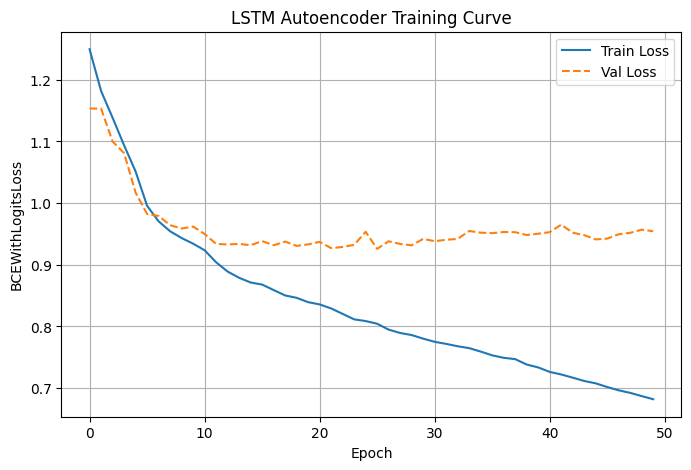

In [5]:
# Plot Training and Validation Loss (guideline Step 11)
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss', linestyle='-')
plt.plot(val_losses, label='Val Loss', linestyle='--')
plt.legend()
plt.title('LSTM Autoencoder Training Curve')
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogitsLoss')
plt.grid(True)
plt.show()


In [6]:
# Evaluate on Test Set
model.eval()
test_loss = 0.0

with torch.no_grad():
    for batch in test_loader:
        x = batch[0].to(device)
        reconstructed, z = model(x)
        loss = criterion(reconstructed, x)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)
print(f"Test Loss: {avg_test_loss:.6f}")


Test Loss: 0.958938


In [7]:
# Save Model and Loss Values
torch.save(model.state_dict(), "../outputs/checkpoints/lstm_autoencoder.pth")
np.save("../outputs/plots/task1_train_losses.npy", np.array(train_losses))
np.save("../outputs/plots/task1_val_losses.npy", np.array(val_losses))
print("Model and loss values saved.")


Model and loss values saved.


In [8]:
# Generate 5 reconstructed MIDI samples from test set
output_dir = Path("../outputs/generated_midis/task1_autoencoder")
output_dir.mkdir(parents=True, exist_ok=True)

model.eval()

with torch.no_grad():
    for i in range(5):
        x = test_tensor[i:i+1].to(device)
        reconstructed, z = model(x)

        # shape: (1, seq_len, pitches) -> (pitches, seq_len)
        reconstructed_probs = torch.sigmoid(reconstructed)
        reconstructed_roll = (reconstructed_probs.squeeze(0).cpu().numpy().T > 0.3).astype(float)

        output_path = output_dir / f"task1_reconstructed_{i+1}.mid"
        piano_roll_to_midi(reconstructed_roll, output_path, fs=16)
        print("Saved:", output_path)


Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_1.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_2.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_3.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_4.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_reconstructed_5.mid


In [9]:
# Save corresponding original MIDI samples
with torch.no_grad():
    for i in range(5):
        original_roll = test_tensor[i].cpu().numpy().T

        output_path = output_dir / f"task1_original_{i+1}.mid"
        piano_roll_to_midi(original_roll, output_path, fs=16)
        print("Saved:", output_path)


Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_1.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_2.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_3.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_4.mid
Saved: ..\outputs\generated_midis\task1_autoencoder\task1_original_5.mid


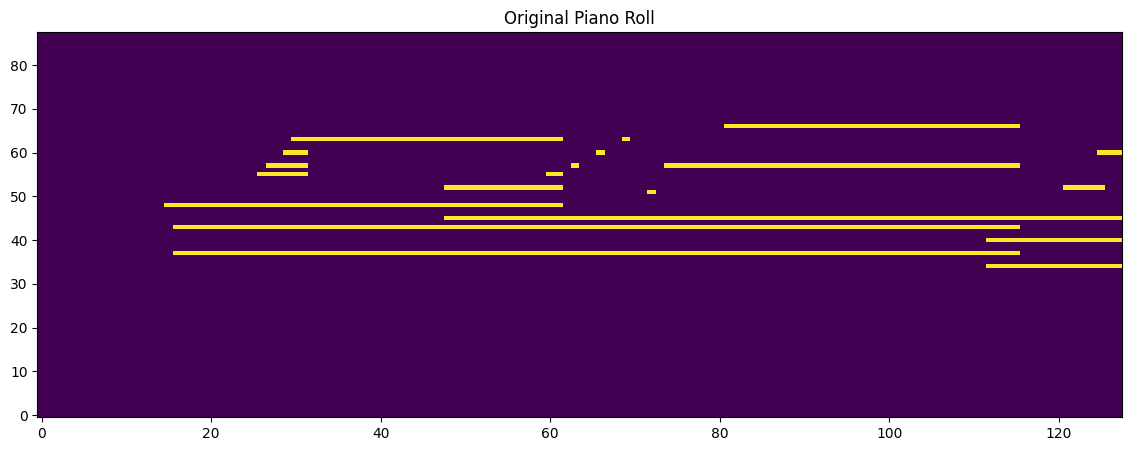

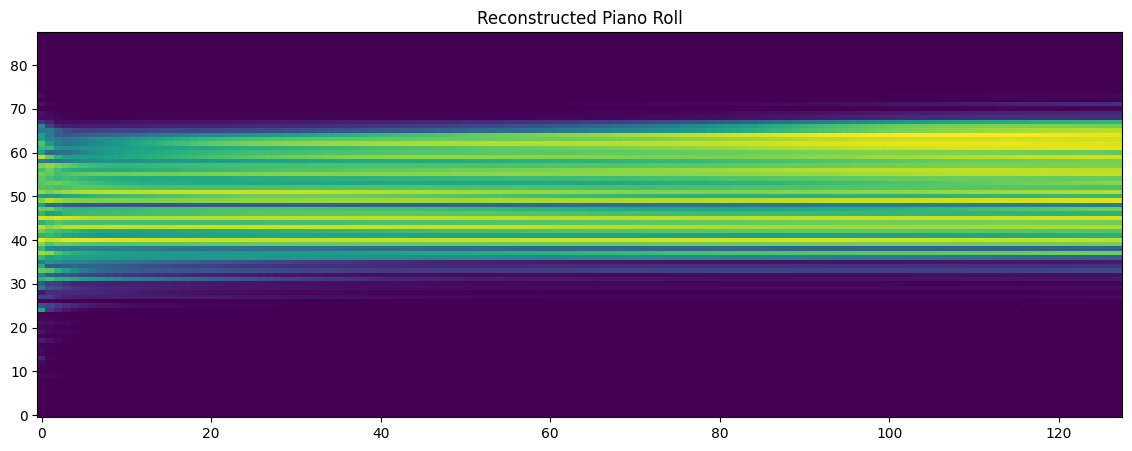

In [10]:
# Visual comparison: Original vs Reconstructed piano roll
i = 0

original = test_tensor[i].cpu().numpy().T

model.eval()
with torch.no_grad():
    x = test_tensor[i:i+1].to(device)
    reconstructed, _ = model(x)
    reconstructed = torch.sigmoid(reconstructed)
    recon = reconstructed.squeeze(0).cpu().numpy().T

plt.figure(figsize=(14, 5))
plt.imshow(original, aspect="auto", origin="lower")
plt.title("Original Piano Roll")
plt.show()

plt.figure(figsize=(14, 5))
plt.imshow(recon, aspect="auto", origin="lower")
plt.title("Reconstructed Piano Roll")
plt.show()
